# Análisis Exploratorio de Datos (EDA) - Dataset de Videos de YouTube para Niños

En este notebook se analiza el dataset de videos de YouTube para detectar contenido inapropiado para niños.

## Descripción del Dataset

**Dataset principal para ENTRENAMIENTO: dataset_groundtruth.csv**
- 4,797 videos anotados manualmente por humanos
- Distribución: 1,513 suitable, 929 disturbing, 419 restricted, 1,936 irrelevant
- Etiquetas 100% confiables para entrenamiento de modelos de ML
- Ubicación: ../dataset_disturbed_youtube_kids/dataset_groundtruth.csv

**Datasets adicionales para PRUEBAS (muestra breve):**
- elsagate_related_videos_parts/ (5 partes .json.gz): 233K videos
- other_child_related_videos_parts/ (3 partes .json.gz): 155K videos
- random_videos_parts/ (8 partes .json.gz): 482K videos
- popular_videos.json.gz: 11K videos

**Nota**: Los datasets adicionales se usarán para pruebas/predicciones con el modelo ya entrenado. Solo se analizará una muestra breve de cada uno.

In [58]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import gzip
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Ruta base de los datasets
DATA_PATH = '../dataset_disturbed_youtube _for_kids'

# PARTE 1: EDA DE GROUNDTRUTH.CSV (DATASET DE ENTRENAMIENTO)

## 1. Carga de Datos de Entrenamiento

In [59]:
# Cargar ground truth (dataset principal con etiquetas manuales)
print("Cargando dataset de ENTRENAMIENTO...")
groundtruth_path = os.path.join(DATA_PATH, 'dataset_groundtruth.csv')
df_train = pd.read_csv(groundtruth_path)

print(f"• dataset_groundtruth.csv: {len(df_train)} videos (anotados manualmente)")
print(f"Columnas: {list(df_train.columns)}")

Cargando dataset de ENTRENAMIENTO...
• dataset_groundtruth.csv: 4797 videos (anotados manualmente)
Columnas: ['video_id', 'title', 'description', 'channel_id', 'channel_title', 'published_at', 'category_id', 'tags', 'duration_iso', 'duration_seconds', 'definition', 'caption', 'licensed_content', 'view_count', 'like_count', 'dislike_count', 'comment_count', 'favorite_count', 'classification_label', 'prediction', 'is_ground_truth', 'source_dataset']


## 2. Distribución de Clases en Dataset de Entrenamiento

In [60]:
# Contar etiquetas de clasificación (ground truth)
print("DISTRIBUCIÓN DE CLASES EN GROUND TRUTH (ENTRENAMIENTO)")
print("="*60)

label_counts = df_train['classification_label'].value_counts()

print(f"Total de videos de entrenamiento: {len(df_train):,}")
print(f"\nDistribución de clases:")
for label, count in label_counts.items():
    print(f" – {label}: {count:,} ({count/len(df_train)*100:.1f}%)")

DISTRIBUCIÓN DE CLASES EN GROUND TRUTH (ENTRENAMIENTO)
Total de videos de entrenamiento: 4,797

Distribución de clases:
 – irrelevant: 1,936 (40.4%)
 – suitable: 1,513 (31.5%)
 – disturbing: 929 (19.4%)
 – restricted: 419 (8.7%)


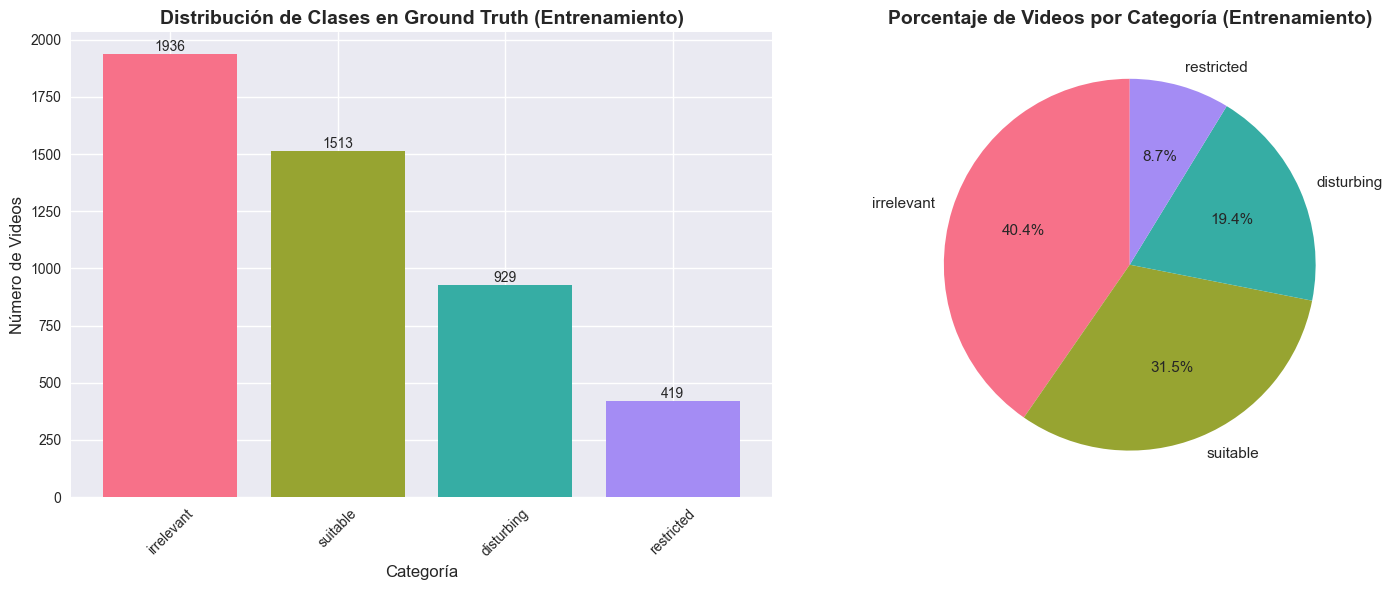

In [61]:
# Visualizar distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras
bars = axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette("husl", len(label_counts)))
axes[0].set_title("Distribución de Clases en Ground Truth (Entrenamiento)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Categoría", fontsize=12)
axes[0].set_ylabel("Número de Videos", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Añadir etiquetas de valor
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)

# Gráfico de pie
colors = sns.color_palette("husl", len(label_counts))
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title("Porcentaje de Videos por Categoría (Entrenamiento)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Primeras Filas del Dataset

In [62]:
print("Primeras filas del dataset de entrenamiento:")
df_train.head()

Primeras filas del dataset de entrenamiento:


,video_id,title,description,channel_id,channel_title,published_at,category_id,tags,duration_iso,duration_seconds,...,licensed_content,view_count,like_count,dislike_count,comment_count,favorite_count,classification_label,prediction,is_ground_truth,source_dataset
0,RYq0wVVXSJo,✅ Frozen Princess Elsa The Mermaid Puzzle Game...,Jigsaw puzzle children game with Disney Frozen...,UC_Q51pfEm5-L7Q7N-i1W3wg,GamesKidsChannel,2018-05-06T09:35:46.000Z,20,video games|puzzles|Puzzle Games For Kids|puzz...,PT2M30S,150.0,...,True,121226.0,111.0,48.0,0.0,0,suitable,NaN,1,groundtruth
1,w0xGZkViRYU,Kids Master Cooking Play Toy Kitchen A Fun Kit...,Subscribe ....Like .....Share amazon : http:/...,UCAqHpEnYCNEbBSOtSKI6D1A,Kids-Toys,2014-03-16T11:35:25.000Z,1,toys|toy car|die-cast|cars playset|car smashes...,PT46S,46.0,...,False,1723623.0,875.0,280.0,32.0,0,suitable,NaN,1,groundtruth
2,NoaicfO02bA,Маргарита и Лера играют в хокей,Маргарита и Лера играют в хокей\nМаргарита с Л...,UCYEHNnr_6XP-NY738hwXL1g,* KIDS Daisy Best,2018-06-03T06:37:58.000Z,24,Маргарита|Лера|девочки|дети|сестрички|подружки...,PT10M7S,607.0,...,True,59130.0,145.0,44.0,8.0,0,suitable,NaN,1,groundtruth
3,5pd5Lv71Nm0,Undress Display Model Spider-Man Costume Replica,Here's how the suit is undressed from the mann...,UC0AeIM8xtiFAgT_N1inUQxQ,SpideyPlanet,2015-12-16T11:15:03.000Z,1,spiderman costume|spiderman suit|spider man co...,PT1M31S,91.0,...,True,646516.0,776.0,205.0,33.0,0,suitable,NaN,1,groundtruth
4,PUHJKlyFD3c,Frozen Elsa Confused Anna is Pregnant with Ryd...,NaN,UCxSjoRRrprrbX9uYIRVrerg,Kid's Toys,2018-04-25T10:18:06.000Z,22,NaN,PT16M4S,964.0,...,False,742.0,11.0,1.0,0.0,0,disturbing,NaN,1,groundtruth


## 4. Estadísticas Descriptivas del Dataset de Entrenamiento

In [63]:
# Estadísticas descriptivas de variables numéricas
numeric_cols = ['view_count', 'like_count', 'dislike_count', 'comment_count', 'duration_seconds']
df_train_numeric = df_train[numeric_cols].copy()

print("Estadísticas descriptivas (Dataset de Entrenamiento):")
print(df_train_numeric.describe())

Estadísticas descriptivas (Dataset de Entrenamiento):
         view_count    like_count  dislike_count  comment_count  \
count  4.794000e+03  4.669000e+03   4.669000e+03    4569.000000   
mean   6.142717e+06  2.687813e+04   3.718921e+03    2378.405559   
std    4.383654e+07  1.554788e+05   2.542508e+04   12849.850888   
min    0.000000e+00  0.000000e+00   0.000000e+00       0.000000   
25%    1.140000e+03  1.000000e+01   1.000000e+00       1.000000   
50%    9.009350e+04  5.020000e+02   5.300000e+01      49.000000   
75%    1.775453e+06  1.012200e+04   1.097000e+03     763.000000   
max    1.664660e+09  4.392637e+06   1.071513e+06  323267.000000   

       duration_seconds  
count       4796.000000  
mean         752.055880  
std         1986.992251  
min            0.000000  
25%          167.000000  
50%          345.500000  
75%          706.250000  
max        39433.000000  


In [64]:
# Análisis de valores faltantes
print("Valores faltantes por columna (Dataset de Entrenamiento):")
missing_values = df_train.isnull().sum()
missing_percentage = (missing_values / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

Valores faltantes por columna (Dataset de Entrenamiento):
                  Missing Count  Missing Percentage
description                 506           10.548259
tags                        883           18.407338
duration_iso                  1            0.020846
duration_seconds              1            0.020846
definition                    1            0.020846
caption                       1            0.020846
licensed_content              1            0.020846
view_count                    3            0.062539
like_count                  128            2.668334
dislike_count               128            2.668334
comment_count               228            4.752971
prediction                 4797          100.000000


## 5. Métricas de Engagement por Categoría (Entrenamiento)

In [65]:
# Estadísticas de engagement por categoría
engagement_metrics = ['view_count', 'like_count', 'comment_count']

for metric in engagement_metrics:
    print(f"\n{'='*50}")
    print(f"{metric.upper()} por categoría (Entrenamiento):")
    print(f"{'='*50}")
    
    stats_by_category = df_train.groupby('classification_label')[metric].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    print(stats_by_category)


VIEW_COUNT por categoría (Entrenamiento):
                      count         mean     median          std  min  \
classification_label                                                    
disturbing              929   3193286.59    39144.0  15452148.11  0.0   
irrelevant             1934   3486723.52    10436.0  29164201.75  0.0   
restricted              419   8272591.13  1348394.0  21829769.40  1.0   
suitable               1512  10761959.60   407330.0  68498396.60  0.0   

                               max  
classification_label                
disturbing            3.416299e+08  
irrelevant            6.998951e+08  
restricted            1.945691e+08  
suitable              1.664660e+09  

LIKE_COUNT por categoría (Entrenamiento):
                      count      mean  median        std  min        max
classification_label                                                    
disturbing              921  18536.99   202.0   82705.15  0.0  1403940.0
irrelevant             1908  35003

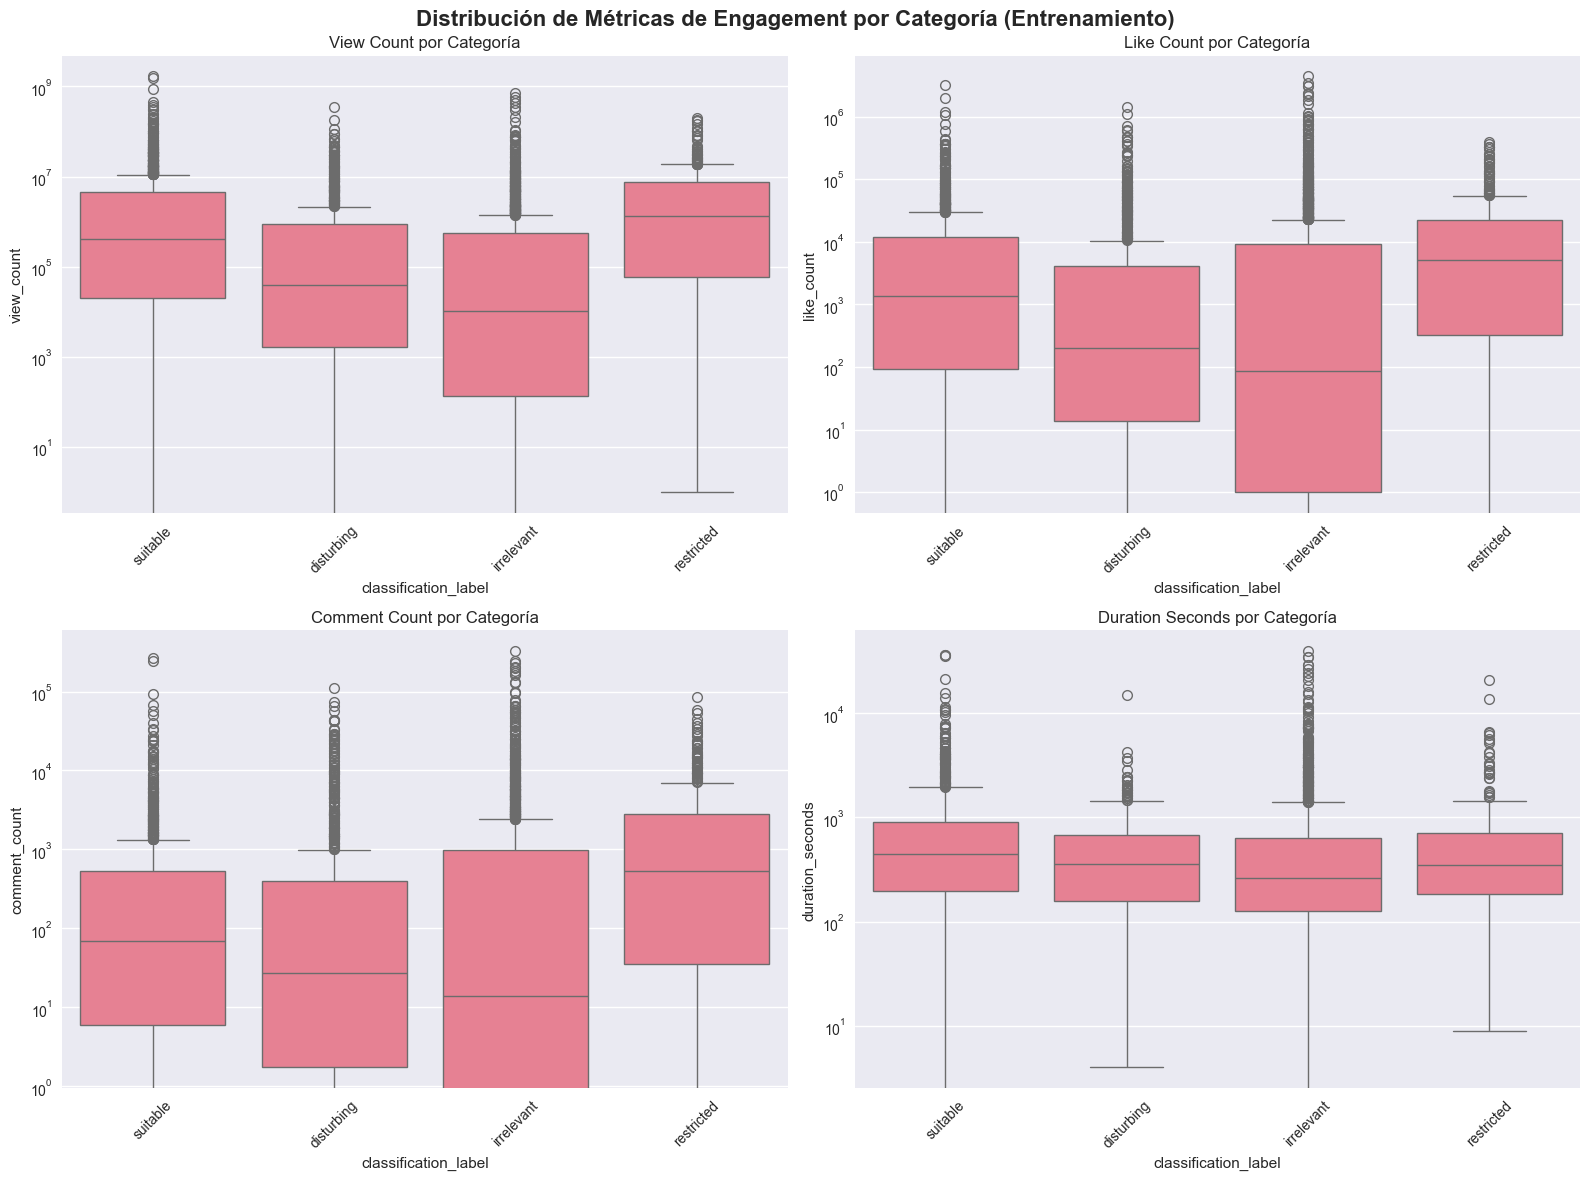

In [66]:
# Visualizar engagement por categoría
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Distribución de Métricas de Engagement por Categoría (Entrenamiento)", fontsize=16, fontweight='bold')

# View count
sns.boxplot(data=df_train, x='classification_label', y='view_count', ax=axes[0,0])
axes[0,0].set_title("View Count por Categoría")
axes[0,0].set_yscale('log')
axes[0,0].tick_params(axis='x', rotation=45)

# Like count
sns.boxplot(data=df_train, x='classification_label', y='like_count', ax=axes[0,1])
axes[0,1].set_title("Like Count por Categoría")
axes[0,1].set_yscale('log')
axes[0,1].tick_params(axis='x', rotation=45)

# Comment count
sns.boxplot(data=df_train, x='classification_label', y='comment_count', ax=axes[1,0])
axes[1,0].set_title("Comment Count por Categoría")
axes[1,0].set_yscale('log')
axes[1,0].tick_params(axis='x', rotation=45)

# Duration seconds
sns.boxplot(data=df_train, x='classification_label', y='duration_seconds', ax=axes[1,1])
axes[1,1].set_title("Duration Seconds por Categoría")
axes[1,1].set_yscale('log')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Categorías de YouTube (Entrenamiento)

In [67]:
# Distribución de category_id
category_dist = df_train['category_id'].value_counts().head(15)
print("Top 15 categorías de YouTube (Dataset de Entrenamiento):")
print(category_dist)

Top 15 categorías de YouTube (Dataset de Entrenamiento):
category_id
24    1223
22    1088
1      815
20     365
27     291
10     266
23     220
26     114
25     106
17      97
2       55
28      53
19      39
15      29
29      25
Name: count, dtype: int64


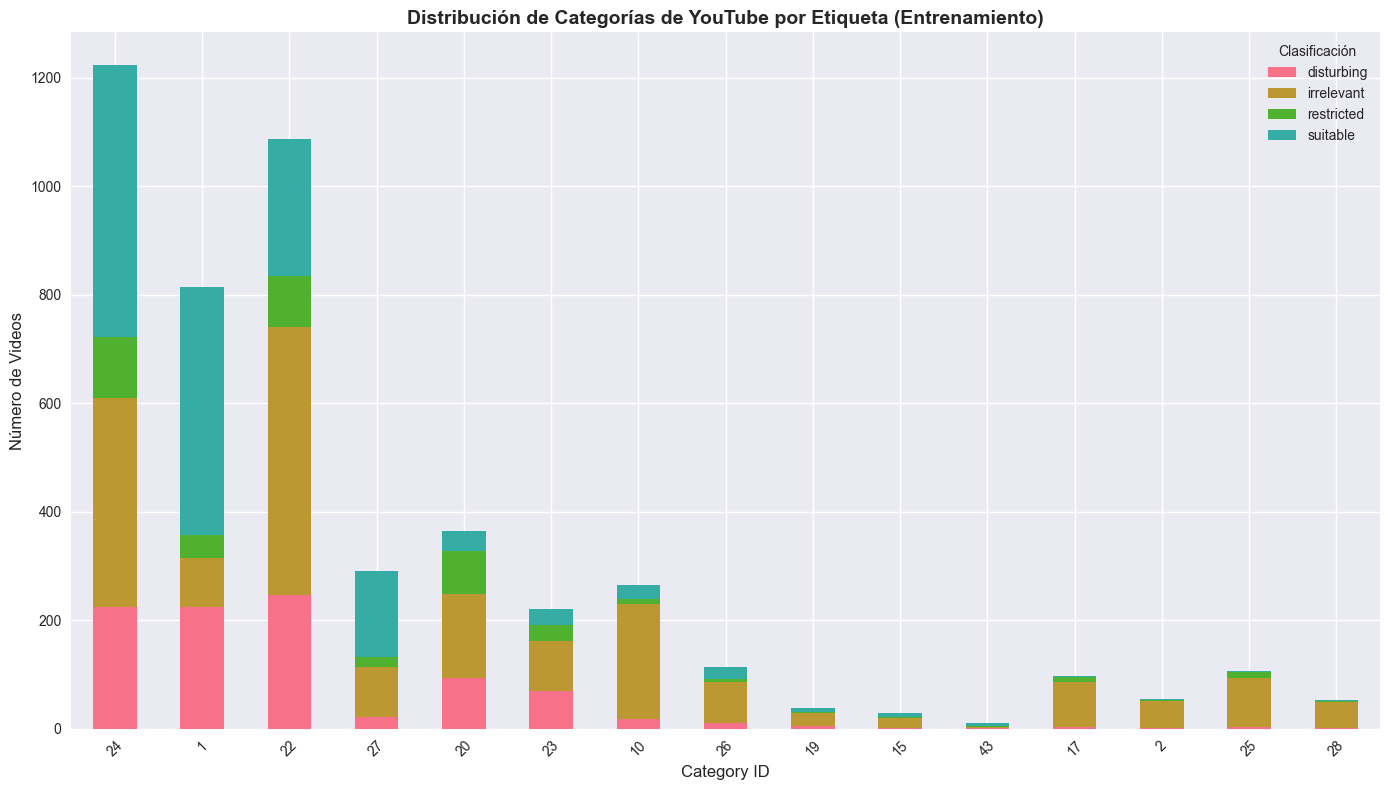

In [68]:
# Visualizar categorías por etiqueta de clasificación
category_by_label = pd.crosstab(df_train['category_id'], df_train['classification_label'])
category_by_label = category_by_label.sort_values(by='suitable', ascending=False).head(15)

category_by_label.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title("Distribución de Categorías de YouTube por Etiqueta (Entrenamiento)", fontsize=14, fontweight='bold')
plt.xlabel("Category ID", fontsize=12)
plt.ylabel("Número de Videos", fontsize=12)
plt.legend(title="Clasificación")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Duración de Videos (Entrenamiento)

In [69]:
# Duración por categoría (ya está en segundos en el CSV)
duration_by_category = df_train.groupby('classification_label')['duration_seconds'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print("Duración por categoría (segundos) - Dataset de Entrenamiento:")
print(duration_by_category)

Duración por categoría (segundos) - Dataset de Entrenamiento:
                      count    mean  median      std  min      max
classification_label                                              
disturbing              929  508.71   359.0   656.71  4.0  14959.0
irrelevant             1936  785.71   264.0  2401.49  0.0  39433.0
restricted              419  703.29   350.0  1471.53  9.0  20826.0
suitable               1512  872.00   443.5  2055.90  0.0  36524.0


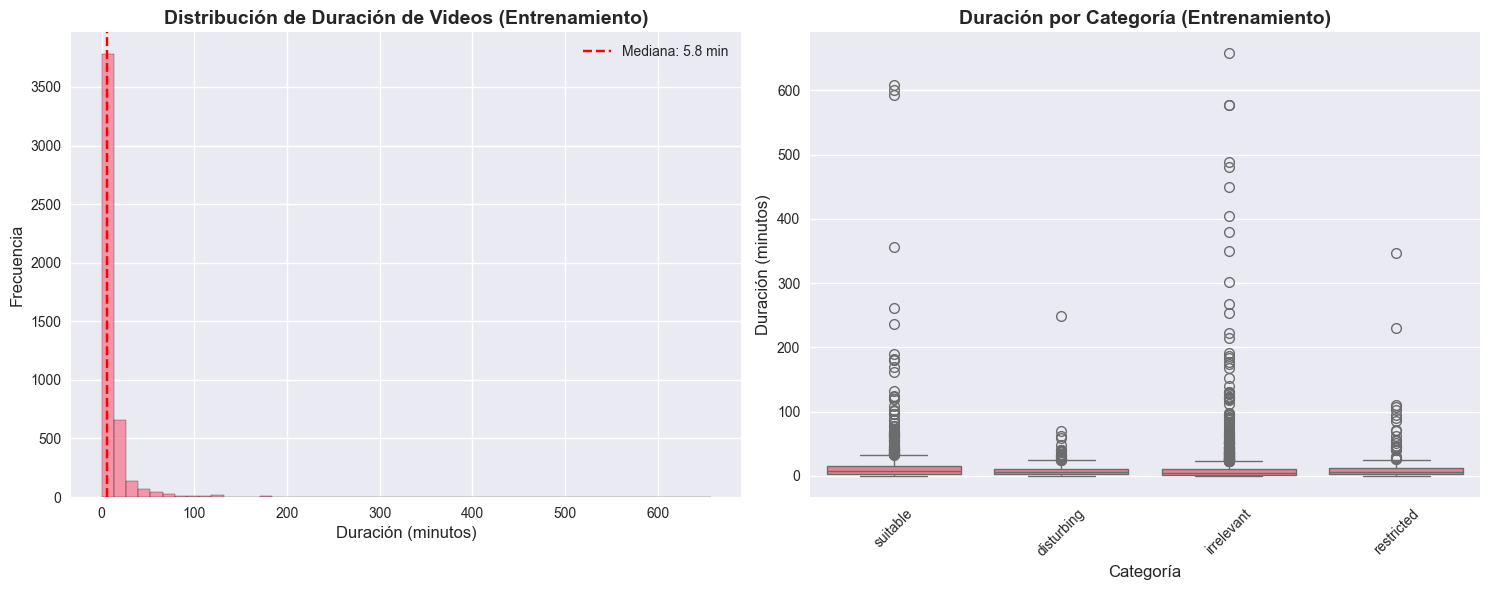

In [70]:
# Visualizar distribución de duración
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma de duración
df_train['duration_minutes'] = df_train['duration_seconds'] / 60
axes[0].hist(df_train['duration_minutes'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title("Distribución de Duración de Videos (Entrenamiento)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Duración (minutos)", fontsize=12)
axes[0].set_ylabel("Frecuencia", fontsize=12)
axes[0].axvline(df_train['duration_minutes'].median(), color='red', linestyle='--', 
              label=f"Mediana: {df_train["duration_minutes"].median():.1f} min")
axes[0].legend()

# Boxplot por categoría
sns.boxplot(data=df_train, x='classification_label', y='duration_minutes', ax=axes[1])
axes[1].set_title("Duración por Categoría (Entrenamiento)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Categoría", fontsize=12)
axes[1].set_ylabel("Duración (minutos)", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Calidad de Video (Entrenamiento)

In [71]:
# Distribución de definición de video
definition_dist = df_train['definition'].value_counts()
print("Distribución de definición de video (Dataset de Entrenamiento):")
print(definition_dist)

Distribución de definición de video (Dataset de Entrenamiento):
definition
hd    3748
sd    1048
Name: count, dtype: int64


In [72]:
# Definición por categoría
definition_by_category = pd.crosstab(df_train['definition'], df_train['classification_label'])
print("Definición por categoría (Dataset de Entrenamiento):")
print(definition_by_category)

Definición por categoría (Dataset de Entrenamiento):
classification_label  disturbing  irrelevant  restricted  suitable
definition                                                        
hd                           771        1456         326      1195
sd                           158         480          93       317


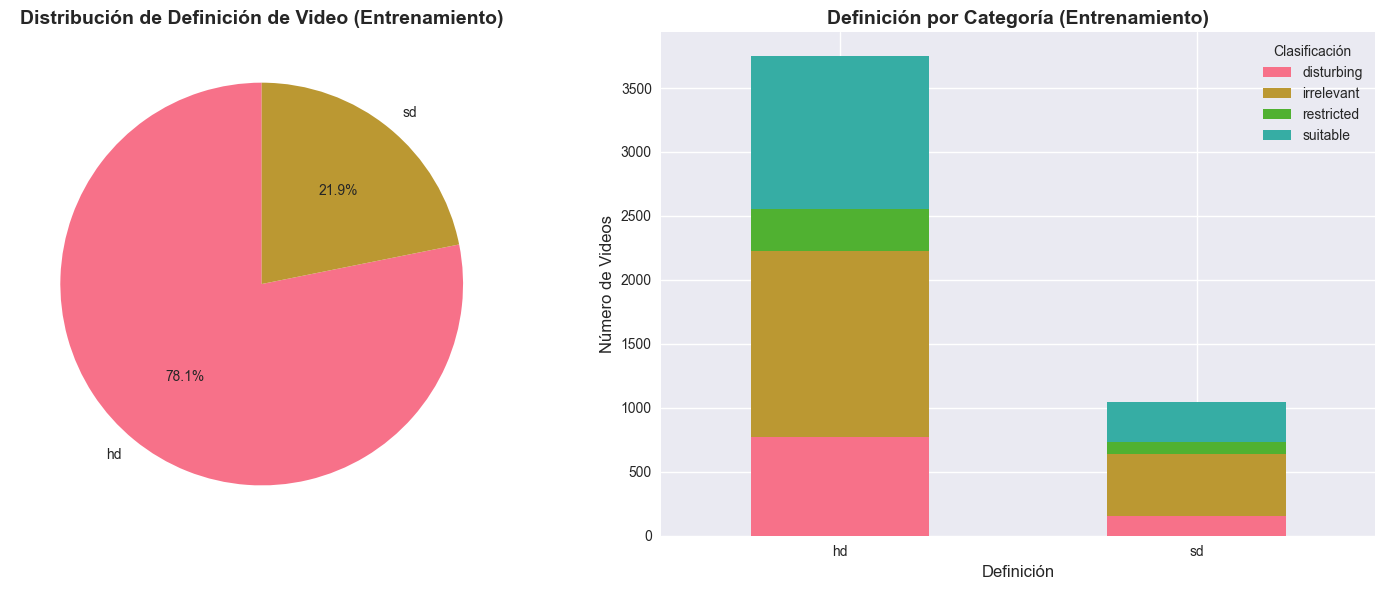

In [73]:
# Visualizar definición por categoría
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart de definición
definition_dist.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title("Distribución de Definición de Video (Entrenamiento)", fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Stacked bar por categoría
definition_by_category.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title("Definición por Categoría (Entrenamiento)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Definición", fontsize=12)
axes[1].set_ylabel("Número de Videos", fontsize=12)
axes[1].legend(title="Clasificación")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 9. Análisis de Tags (Entrenamiento)

In [74]:
# Extraer todos los tags (el CSV ya tiene tags como strings)
all_tags = []
for tags in df_train['tags'].dropna():
    if isinstance(tags, str):
        # Los tags pueden venir como string separado por comas o como lista
        if tags.startswith('[') and tags.endswith(']'):
            # Es una lista como string
            try:
                tag_list = eval(tags)
                if isinstance(tag_list, list):
                    all_tags.extend(tag_list)
            except:
                pass
        else:
            # Es string separado por comas
            tag_list = tags.split(',')
            all_tags.extend([tag.strip() for tag in tag_list])

# Contar frecuencia de tags
tag_counter = Counter(all_tags)
print(f"Total de tags únicos (Dataset de Entrenamiento): {len(tag_counter)}")
print(f"Total de tags (con repeticiones): {len(all_tags)}")

Total de tags únicos (Dataset de Entrenamiento): 3705
Total de tags (con repeticiones): 3914


In [75]:
# Top 20 tags más frecuentes
top_tags = tag_counter.most_common(20)
tags_df = pd.DataFrame(top_tags, columns=['Tag', 'Frequency'])
print("Top 20 tags más frecuentes (Dataset de Entrenamiento):")
print(tags_df)

Top 20 tags más frecuentes (Dataset de Entrenamiento):
                                                  Tag  Frequency
0   Foster's|Home|for|Imaginary|Friends|Foster's H...         13
1   thomas jerry|tom a jerry|tom and jarry|tom and...         12
2   tom and jerry|episodes|english|tom and jerry f...         11
3                                     YouTube Capture          9
4   pj masks|pj masks disney|disney junior|pj mask...          8
5   Cartoon|full episode|YTV|kids tv|retro cartoon...          7
6   Disney Disney Videos Disney YouTube The Walt D...          7
7                                      YouTube Editor          6
8                                              iMovie          6
9   tom and jerry|episodes|english|cartoons for ki...          6
10  peppa pig|peppa pig english episodes|peppa pig...          6
11  Jayce And The Wheeled Warriors (TV Program)|Ac...          6
12  “Zig et Sharko”|“Zig und Sharko”|“Zig y sharko...          6
13         Galaxy|Galaxy High Schoo

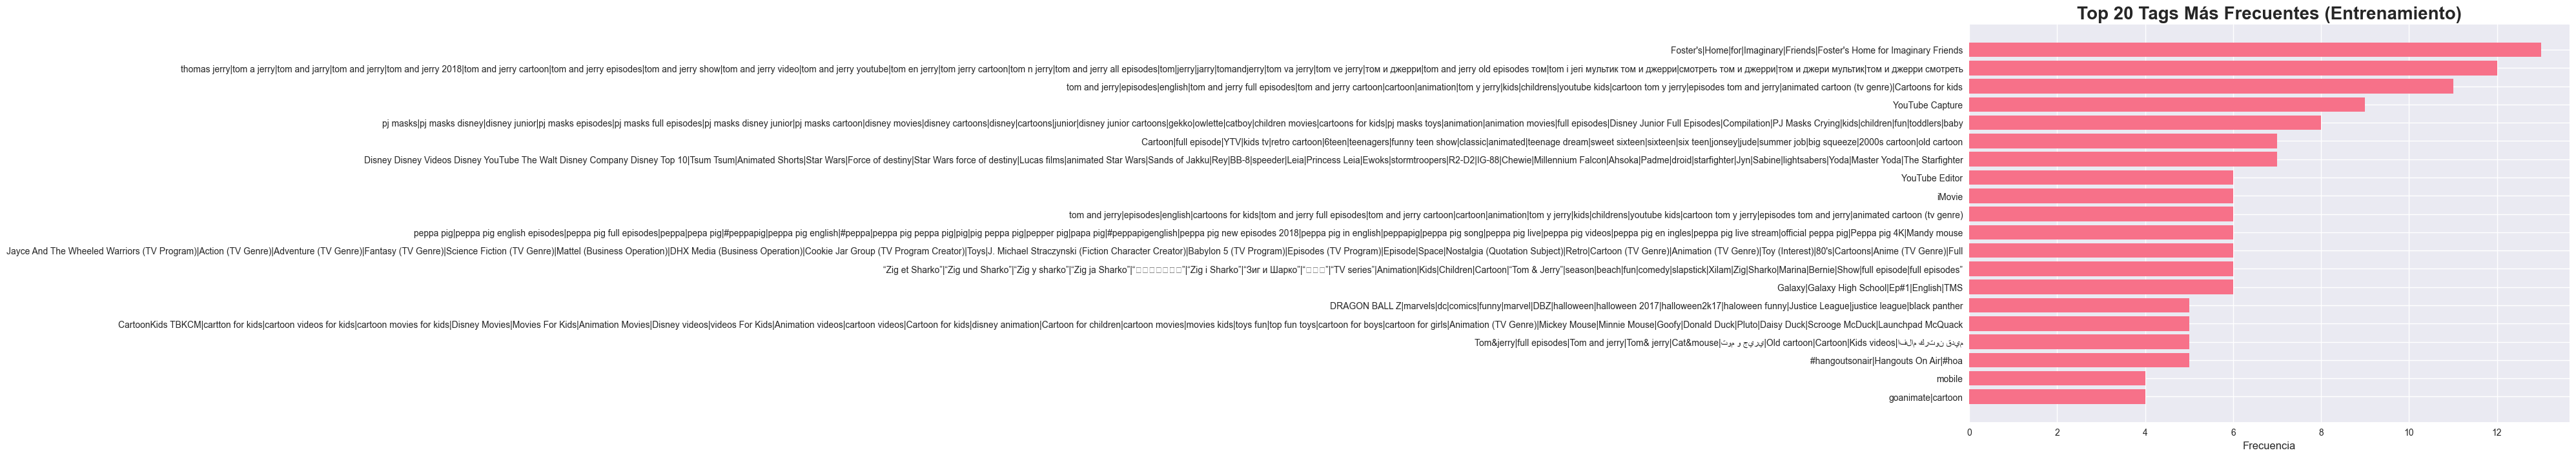

In [76]:
# Visualizar top tags
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_tags)), [tag[1] for tag in top_tags])
plt.yticks(range(len(top_tags)), [tag[0] for tag in top_tags])
plt.xlabel('Frecuencia', fontsize=12)
plt.title('Top 20 Tags Más Frecuentes (Entrenamiento)', fontsize=20, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Análisis de Títulos (Entrenamiento)

In [77]:
# Longitud de títulos
df_train['title_length'] = df_train['title'].str.len()
df_train['title_word_count'] = df_train['title'].str.split().str.len()

print("Estadísticas de longitud de títulos (Dataset de Entrenamiento):")
print(df_train[['title_length', 'title_word_count']].describe())

Estadísticas de longitud de títulos (Dataset de Entrenamiento):
       title_length  title_word_count
count   4797.000000       4797.000000
mean      53.739212          9.342297
std       24.917959          4.366306
min        1.000000          1.000000
25%       34.000000          6.000000
50%       51.000000          9.000000
75%       73.000000         13.000000
max      113.000000         22.000000


In [78]:
# Longitud de título por categoría
title_stats_by_category = df_train.groupby('classification_label')[['title_length', 'title_word_count']].agg([
    'mean', 'median', 'std']).round(2)
print("Estadísticas de títulos por categoría (Dataset de Entrenamiento):")
print(title_stats_by_category)

Estadísticas de títulos por categoría (Dataset de Entrenamiento):
                     title_length               title_word_count             
                             mean median    std             mean median   std
classification_label                                                         
disturbing                  58.98   56.0  28.18            10.04   10.0  4.55
irrelevant                  46.80   43.5  22.82             8.12    8.0  4.17
restricted                  44.79   42.0  20.88             7.79    7.0  3.70
suitable                    61.88   61.0  22.98            10.91   11.0  4.05


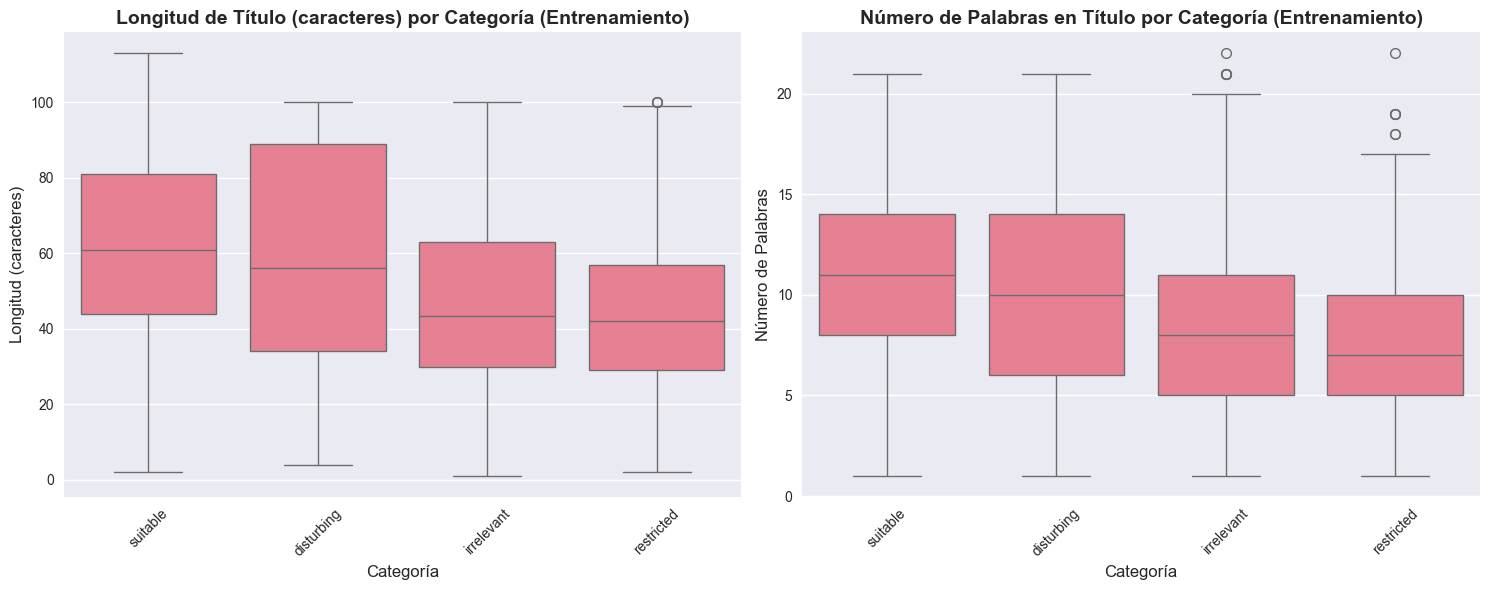

In [79]:
# Visualizar longitud de títulos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot de longitud de caracteres
sns.boxplot(data=df_train, x='classification_label', y='title_length', ax=axes[0])
axes[0].set_title("Longitud de Título (caracteres) por Categoría (Entrenamiento)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Categoría", fontsize=12)
axes[0].set_ylabel("Longitud (caracteres)", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Boxplot de número de palabras
sns.boxplot(data=df_train, x='classification_label', y='title_word_count', ax=axes[1])
axes[1].set_title("Número de Palabras en Título por Categoría (Entrenamiento)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Categoría", fontsize=12)
axes[1].set_ylabel("Número de Palabras", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 11. Resumen del Dataset de Entrenamiento

In [80]:
# Resumen estadístico general del dataset de entrenamiento
print("="*60)
print("RESUMEN DEL DATASET DE ENTRENAMIENTO (GROUNDTRUTH)")
print("="*60)

print(f"\nTotal de videos de entrenamiento: {len(df_train):,}")
print(f"\nDistribución de clases:")
for label, count in label_counts.items():
    print(f"  - {label}: {count:,} ({count/len(df_train)*100:.1f}%)")

print(f"\nEstadísticas de engagement:")
print(f"  - Vistas totales: {df_train['view_count'].sum():,}")
print(f"  - Promedio de vistas: {df_train['view_count'].mean():,.0f}")
print(f"  - Promedio de likes: {df_train['like_count'].mean():,.0f}")
print(f"  - Promedio de comentarios: {df_train['comment_count'].mean():,.0f}")

print(f"\nEstadísticas de contenido:")
print(f"  - Duración promedio: {df_train['duration_minutes'].mean():.1f} minutos")
print(f"  - Duración mediana: {df_train['duration_minutes'].median():.1f} minutos")
print(f"  - Longitud promedio de título: {df_train['title_length'].mean():.1f} caracteres")
print(f"  - Número promedio de palabras en título: {df_train['title_word_count'].mean():.1f}")

print(f"\nCalidad de video:")
for definition, count in definition_dist.items():
    print(f"  - {definition}: {count} ({count/len(df_train)*100:.1f}%)")

print(f"\nDiversidad de contenido:")
print(f"  - Categorías de YouTube únicas: {df_train['category_id'].nunique()}")
print(f"  - Canales únicos: {df_train['channel_title'].nunique()}")
print(f"  - Tags únicos: {len(tag_counter)}")

print(f"\nUSO DEL DATASET:")
print(f" • Este dataset (dataset_groundtruth.csv) se usará para ENTRENAR el modelo")
print(f" • Tiene etiquetas 100% confiables (anotaciones manuales humanas)")
print(f" • Los otros datasets se usarán para PRUEBAS y predicciones")

RESUMEN DEL DATASET DE ENTRENAMIENTO (GROUNDTRUTH)

Total de videos de entrenamiento: 4,797

Distribución de clases:
  - irrelevant: 1,936 (40.4%)
  - suitable: 1,513 (31.5%)
  - disturbing: 929 (19.4%)
  - restricted: 419 (8.7%)

Estadísticas de engagement:
  - Vistas totales: 29,448,185,127.0
  - Promedio de vistas: 6,142,717
  - Promedio de likes: 26,878
  - Promedio de comentarios: 2,378

Estadísticas de contenido:
  - Duración promedio: 12.5 minutos
  - Duración mediana: 5.8 minutos
  - Longitud promedio de título: 53.7 caracteres
  - Número promedio de palabras en título: 9.3

Calidad de video:
  - hd: 3748 (78.1%)
  - sd: 1048 (21.8%)

Diversidad de contenido:
  - Categorías de YouTube únicas: 17
  - Canales únicos: 3811
  - Tags únicos: 3705

USO DEL DATASET:
 • Este dataset (dataset_groundtruth.csv) se usará para ENTRENAR el modelo
 • Tiene etiquetas 100% confiables (anotaciones manuales humanas)
 • Los otros datasets se usarán para PRUEBAS y predicciones


# PARTE 2: EDA BREVE DE DATASETS ADICIONALES (PARA PRUEBAS)

## 12. Carga de Muestras de Datasets Adicionales

In [81]:
# Función para cargar muestra de archivos JSON.gz
def load_jsonl_gz_sample(file_path, sample_size=1000):
    data = []
    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= sample_size:
                break
            data.append(json.loads(line))
    return data

# Función para cargar muestra de datasets multipart
def load_multipart_jsonl_sample(base_path, folder_name, sample_size=1000):
    data = []
    folder_path = os.path.join(base_path, folder_name)
    
    if os.path.exists(folder_path):
        # Obtener el primer archivo part_*.json.gz
        part_files = sorted([f for f in os.listdir(folder_path) if f.startswith('part_') and f.endswith('.json.gz')])
        
        if part_files:
            part_path = os.path.join(folder_path, part_files[0])
            print(f"  Cargando muestra de {part_files[0]}...")
            data = load_jsonl_gz_sample(part_path, sample_size)
    else:
        print(f"  Carpeta {folder_name} no encontrada")
    
    return data

# Cargar muestras de datasets adicionales para pruebas
print("Cargando MUESTRAS de datasets adicionales para PRUEBAS...")

# Cargar muestra de elsagate (primera parte)
print("Cargando muestra de elsagate_related_videos...")
elsagate_sample = load_multipart_jsonl_sample(DATA_PATH, 'elsagate_related_videos_parts', sample_size=1000)
print(f"• elsagate_related_videos: {len(elsagate_sample)} videos (muestra)")

# Cargar muestra de other_child (primera parte)
print("Cargando muestra de other_child_related_videos...")
other_child_sample = load_multipart_jsonl_sample(DATA_PATH, 'other_child_related_videos_parts', sample_size=1000)
print(f"• other_child_related_videos: {len(other_child_sample)} videos (muestra)")

# Cargar muestra de random (primera parte)
print("Cargando muestra de random_videos...")
random_sample = load_multipart_jsonl_sample(DATA_PATH, 'random_videos_parts', sample_size=1000)
print(f"• random_videos: {len(random_sample)} videos (muestra)")

# Cargar muestra de popular (archivo único)
print("Cargando muestra de popular_videos...")
popular_path = os.path.join(DATA_PATH, 'popular_videos.json.gz')
popular_sample = load_jsonl_gz_sample(popular_path, sample_size=1000)
print(f"• popular_videos: {len(popular_sample)} videos (muestra)")

print(f"\nEstas muestras se usarán para análisis exploratorio breve de los datasets de pruebas")

Cargando MUESTRAS de datasets adicionales para PRUEBAS...
Cargando muestra de elsagate_related_videos...
  Cargando muestra de part_01.json.gz...
• elsagate_related_videos: 1000 videos (muestra)
Cargando muestra de other_child_related_videos...
  Cargando muestra de part_01.json.gz...
• other_child_related_videos: 1000 videos (muestra)
Cargando muestra de random_videos...
  Cargando muestra de part_01.json.gz...
• random_videos: 1000 videos (muestra)
Cargando muestra de popular_videos...
• popular_videos: 1000 videos (muestra)

Estas muestras se usarán para análisis exploratorio breve de los datasets de pruebas


## 13. EDA: elsagate_related_videos (Muestra)

In [82]:
# Análisis breve de elsagate_related_videos (muestra)
print("ELSAGATE_RELATED_VIDEOS (MUESTRA)")
print("="*50)

# Distribución de labels vs predicciones
has_groundtruth = [v for v in elsagate_sample if v.get('isGroundTruthVideo', 0) == 1]
has_predictions = [v for v in elsagate_sample if v.get('prediction', '')]

print(f"Total en muestra: {len(elsagate_sample)}")
print(f"Con ground truth (seeds): {len(has_groundtruth)}")
print(f"Con predicciones (recomendados): {len(has_predictions)}")

# Distribución de predicciones
pred_labels = [v.get('prediction', 'unknown') for v in elsagate_sample if v.get('prediction', '')]
pred_counter = Counter(pred_labels)
print(f"\nDistribución de predicciones (muestra):")
for label, count in pred_counter.most_common():
    print(f"  {label}: {count} ({count/len(pred_labels)*100:.1f}%)")

ELSAGATE_RELATED_VIDEOS (MUESTRA)
Total en muestra: 1000
Con ground truth (seeds): 780
Con predicciones (recomendados): 1000

Distribución de predicciones (muestra):
  appropriate: 527 (52.7%)
  inappropriate: 473 (47.3%)


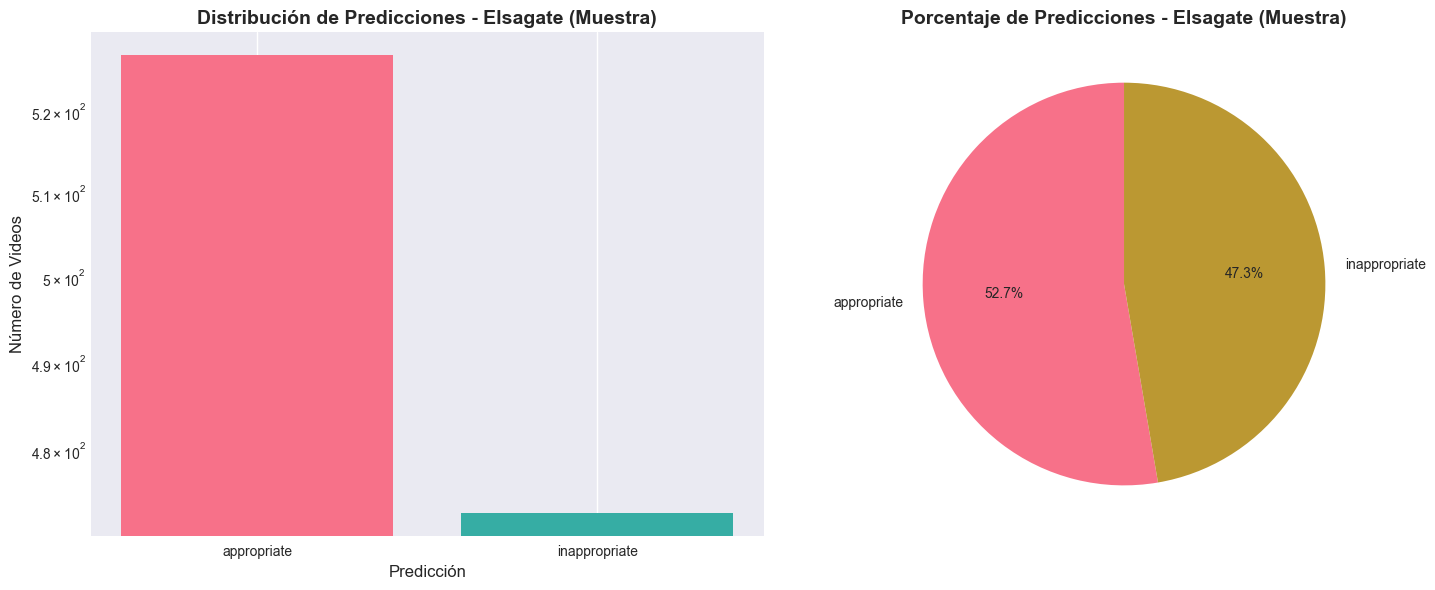

In [83]:
# Visualizar distribución de predicciones en elsagate (muestra)
if pred_counter:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras de predicciones
    df_pred_elsagate = pd.DataFrame.from_dict(pred_counter, orient='index', columns=['count'])
    bars = axes[0].bar(df_pred_elsagate.index, df_pred_elsagate['count'], color=sns.color_palette("husl", len(df_pred_elsagate)))
    axes[0].set_title("Distribución de Predicciones - Elsagate (Muestra)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Predicción", fontsize=12)
    axes[0].set_ylabel("Número de Videos", fontsize=12)
    axes[0].set_yscale('log')

    # Pie chart
    axes[1].pie(df_pred_elsagate['count'], labels=df_pred_elsagate.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title("Porcentaje de Predicciones - Elsagate (Muestra)", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones para visualizar en la muestra de elsagate")

## 14. EDA: other_child_related_videos (Muestra)

In [84]:
# Análisis breve de other_child_related_videos (muestra)
print("OTHER_CHILD_RELATED_VIDEOS (MUESTRA)")
print("="*50)

# Distribución de labels vs predicciones
has_groundtruth = [v for v in other_child_sample if v.get('isGroundTruthVideo', 0) == 1]
has_predictions = [v for v in other_child_sample if v.get('prediction', '')]

print(f"Total en muestra: {len(other_child_sample)}")
print(f"Con ground truth (seeds): {len(has_groundtruth)}")
print(f"Con predicciones (recomendados): {len(has_predictions)}")

# Distribución de predicciones
pred_labels = [v.get('prediction', 'unknown') for v in other_child_sample if v.get('prediction', '')]
pred_counter = Counter(pred_labels)
print(f"\nDistribución de predicciones (muestra):")
for label, count in pred_counter.most_common():
    print(f"  {label}: {count} ({count/len(pred_labels)*100:.1f}%)")

OTHER_CHILD_RELATED_VIDEOS (MUESTRA)
Total en muestra: 1000
Con ground truth (seeds): 70
Con predicciones (recomendados): 1000

Distribución de predicciones (muestra):
  appropriate: 985 (98.5%)
  inappropriate: 15 (1.5%)


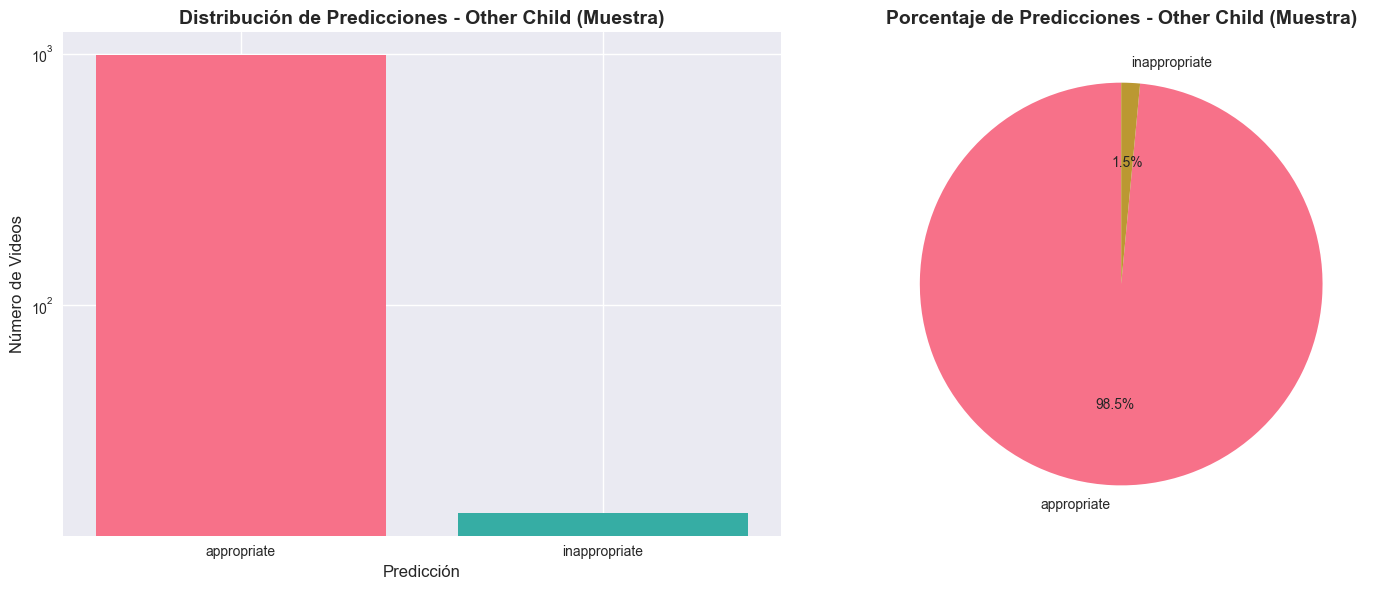

In [85]:
# Visualizar distribución de predicciones en other_child (muestra)
if pred_counter:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras de predicciones
    df_pred_other = pd.DataFrame.from_dict(pred_counter, orient='index', columns=['count'])
    bars = axes[0].bar(df_pred_other.index, df_pred_other['count'], color=sns.color_palette("husl", len(df_pred_other)))
    axes[0].set_title("Distribución de Predicciones - Other Child (Muestra)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Predicción", fontsize=12)
    axes[0].set_ylabel("Número de Videos", fontsize=12)
    axes[0].set_yscale('log')

    # Pie chart
    axes[1].pie(df_pred_other['count'], labels=df_pred_other.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title("Porcentaje de Predicciones - Other Child (Muestra)", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones para visualizar en la muestra de other_child")

## 15. EDA: random_videos (Muestra)

In [86]:
# Análisis breve de random_videos (muestra)
print("RANDOM_VIDEOS (MUESTRA)")
print("="*50)

# Distribución de labels vs predicciones
has_groundtruth = [v for v in random_sample if v.get('isGroundTruthVideo', 0) == 1]
has_predictions = [v for v in random_sample if v.get('prediction', '')]

print(f"Total en muestra: {len(random_sample)}")
print(f"Con ground truth (seeds): {len(has_groundtruth)}")
print(f"Con predicciones (recomendados): {len(has_predictions)}")

# Distribución de predicciones
pred_labels = [v.get('prediction', 'unknown') for v in random_sample if v.get('prediction', '')]
pred_counter = Counter(pred_labels)
print(f"\nDistribución de predicciones (muestra):")
for label, count in pred_counter.most_common():
    print(f"  {label}: {count} ({count/len(pred_labels)*100:.1f}%)")

RANDOM_VIDEOS (MUESTRA)
Total en muestra: 1000
Con ground truth (seeds): 34
Con predicciones (recomendados): 1000

Distribución de predicciones (muestra):
  appropriate: 997 (99.7%)
  inappropriate: 3 (0.3%)


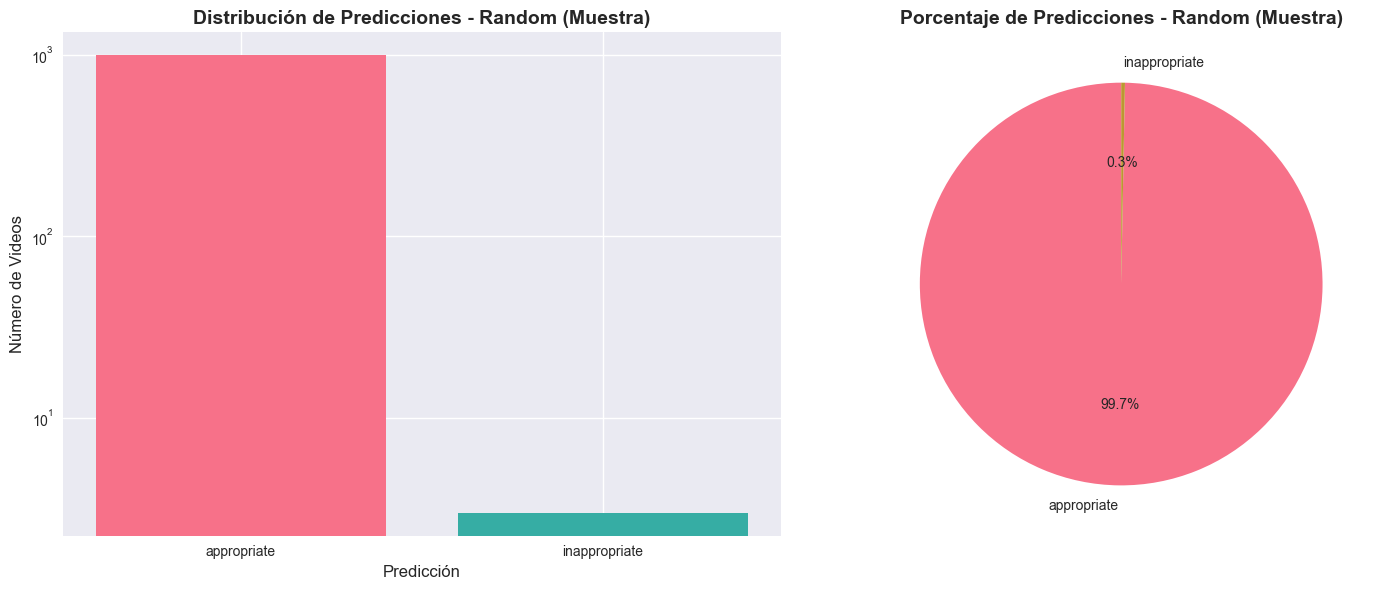

In [87]:
# Visualizar distribución de predicciones en random (muestra)
if pred_counter:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras de predicciones
    df_pred_random = pd.DataFrame.from_dict(pred_counter, orient='index', columns=['count'])
    bars = axes[0].bar(df_pred_random.index, df_pred_random['count'], color=sns.color_palette("husl", len(df_pred_random)))
    axes[0].set_title("Distribución de Predicciones - Random (Muestra)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Predicción", fontsize=12)
    axes[0].set_ylabel("Número de Videos", fontsize=12)
    axes[0].set_yscale('log')

    # Pie chart
    axes[1].pie(df_pred_random['count'], labels=df_pred_random.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title("Porcentaje de Predicciones - Random (Muestra)", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones para visualizar en la muestra de random")

## 16. EDA: popular_videos (Muestra)

In [88]:
# Análisis breve de popular_videos (muestra)
print("POPULAR_VIDEOS (MUESTRA)")
print("="*50)

# Distribución de labels vs predicciones
has_groundtruth = [v for v in popular_sample if v.get('isGroundTruthVideo', 0) == 1]
has_predictions = [v for v in popular_sample if v.get('prediction', '')]

print(f"Total en muestra: {len(popular_sample)}")
print(f"Con ground truth (seeds): {len(has_groundtruth)}")
print(f"Con predicciones (recomendados): {len(has_predictions)}")

# Distribución de predicciones
pred_labels = [v.get('prediction', 'unknown') for v in popular_sample if v.get('prediction', '')]
pred_counter = Counter(pred_labels)
print(f"\nDistribución de predicciones (muestra):")
for label, count in pred_counter.most_common():
    print(f"  {label}: {count} ({count/len(pred_labels)*100:.1f}%)")

POPULAR_VIDEOS (MUESTRA)
Total en muestra: 1000
Con ground truth (seeds): 490
Con predicciones (recomendados): 1000

Distribución de predicciones (muestra):
  appropriate: 973 (97.3%)
  inappropriate: 27 (2.7%)


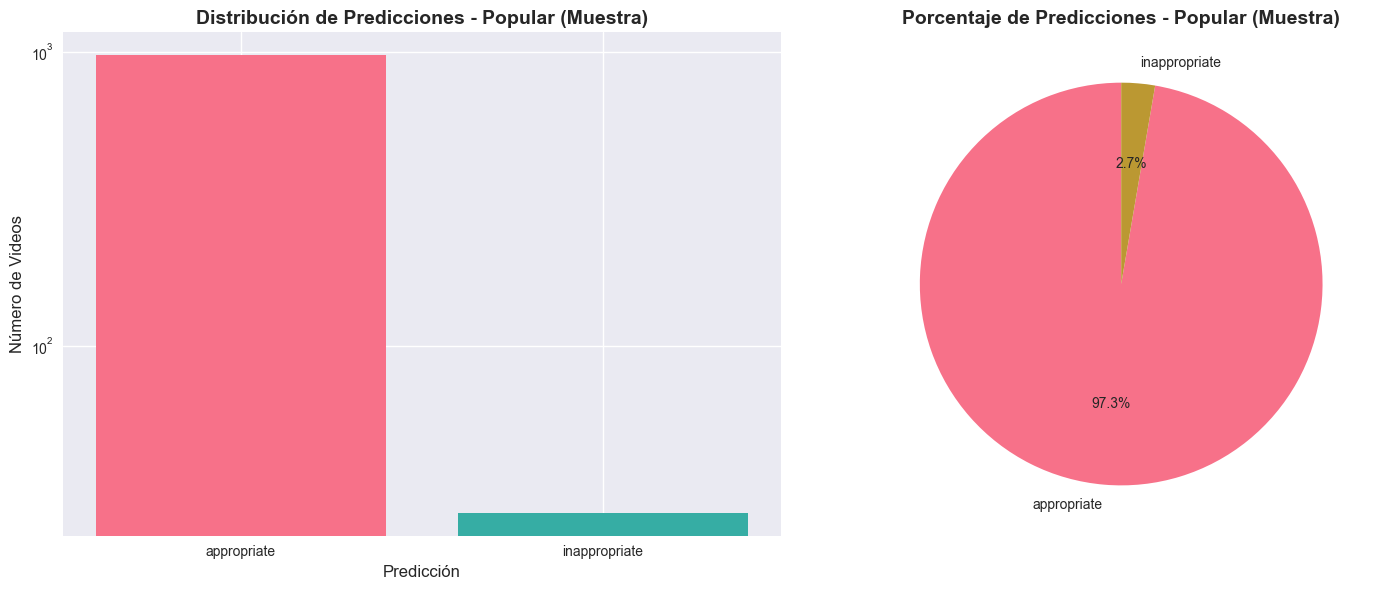

In [89]:
# Visualizar distribución de predicciones en popular (muestra)
if pred_counter:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras de predicciones
    df_pred_popular = pd.DataFrame.from_dict(pred_counter, orient='index', columns=['count'])
    bars = axes[0].bar(df_pred_popular.index, df_pred_popular['count'], color=sns.color_palette("husl", len(df_pred_popular)))
    axes[0].set_title('Distribución de Predicciones - Popular (Muestra)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicción', fontsize=12)
    axes[0].set_ylabel('Número de Videos', fontsize=12)
    axes[0].set_yscale('log')

    # Pie chart
    axes[1].pie(df_pred_popular['count'], labels=df_pred_popular.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Porcentaje de Predicciones - Popular (Muestra)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones para visualizar en la muestra de popular")

## 17. Resumen Final

In [90]:
# Resumen final del análisis
print("="*60)
print("RESUMEN FINAL DEL ANÁLISIS EXPLORATORIO")
print("="*60)

print(f"\nDATASET DE ENTRENAMIENTO (GROUNDTRUTH):")
print(f"  - Fuente: dataset_groundtruth.csv")
print(f"  - Total videos: {len(df_train):,}")
print(f"  - Clases: {', '.join(label_counts.index)}")
print(f"  - Etiquetas: 100% manuales y confiables")
print(f"  - Uso: ENTRENAMIENTO del modelo de ML")

print(f"\nDATASETS ADICIONALES (PRUEBAS - MUESTRAS):")
print(f"  - elsagate_related: {len(elsagate_sample)} videos (muestra de ~233K)")
print(f"  - other_child_related: {len(other_child_sample)} videos (muestra de ~155K)")
print(f"  - random_videos: {len(random_sample)} videos (muestra de ~482K)")
print(f"  - popular_videos: {len(popular_sample)} videos (muestra de ~11K)")
print(f"  - Estructura: Seeds con ground truth + recomendados con predicciones")
print(f"  - Uso: PRUEBAS y predicciones con modelo entrenado")

print(f"\nESTRATEGIA DEL PROYECTO:")
print(f"  1. EDA completo de groundtruth (dataset de entrenamiento)")
print(f"  2. EDA breve de muestras de datasets adicionales (datasets de pruebas)")
print(f"  3. (Próximamente) Feature engineering con groundtruth")
print(f"  4. (Próximamente) Entrenamiento de modelo con groundtruth")
print(f"  5. (Próximamente) Pruebas y predicciones con datasets adicionales")

RESUMEN FINAL DEL ANÁLISIS EXPLORATORIO

DATASET DE ENTRENAMIENTO (GROUNDTRUTH):
  - Fuente: dataset_groundtruth.csv
  - Total videos: 4,797
  - Clases: irrelevant, suitable, disturbing, restricted
  - Etiquetas: 100% manuales y confiables
  - Uso: ENTRENAMIENTO del modelo de ML

DATASETS ADICIONALES (PRUEBAS - MUESTRAS):
  - elsagate_related: 1000 videos (muestra de ~233K)
  - other_child_related: 1000 videos (muestra de ~155K)
  - random_videos: 1000 videos (muestra de ~482K)
  - popular_videos: 1000 videos (muestra de ~11K)
  - Estructura: Seeds con ground truth + recomendados con predicciones
  - Uso: PRUEBAS y predicciones con modelo entrenado

ESTRATEGIA DEL PROYECTO:
  1. EDA completo de groundtruth (dataset de entrenamiento)
  2. EDA breve de muestras de datasets adicionales (datasets de pruebas)
  3. (Próximamente) Feature engineering con groundtruth
  4. (Próximamente) Entrenamiento de modelo con groundtruth
  5. (Próximamente) Pruebas y predicciones con datasets adicionales
